<a href="https://colab.research.google.com/github/samreenshakeel/Heart-Disease-Detection/blob/main/Heart_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Prediction Using Machine Learning & Deep Learning**



# **Load and Data Preprocessing:**

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/Heart Disease.zip')  # Change path if needed
print(df.head())
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Encode categorical columns if needed
# No NaNs or string columns in this dataset

# Feature and target split
X = df.drop('condition', axis=1)
y = df['condition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       29

# **Data Visualization:**

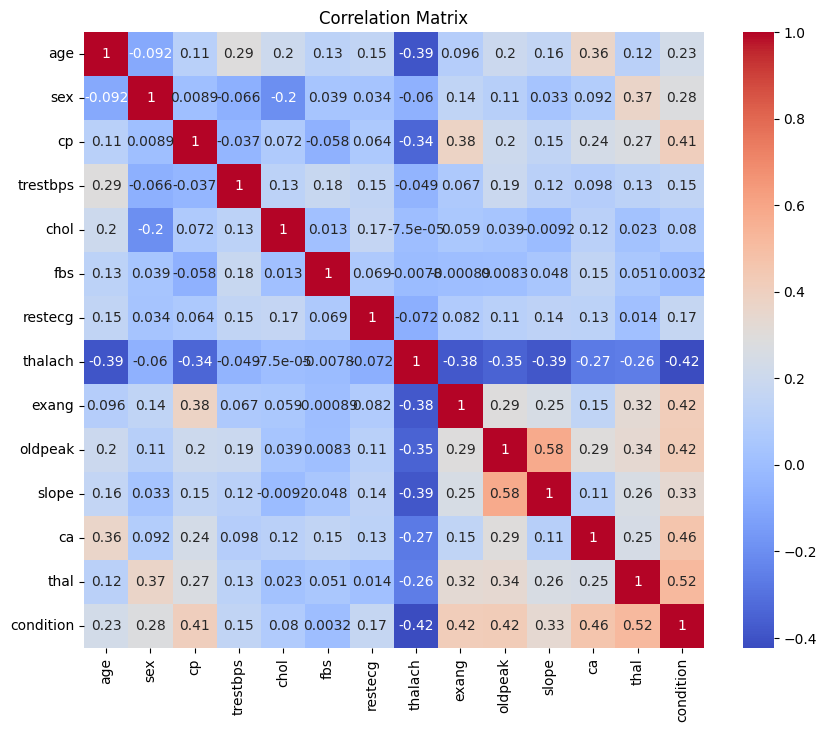

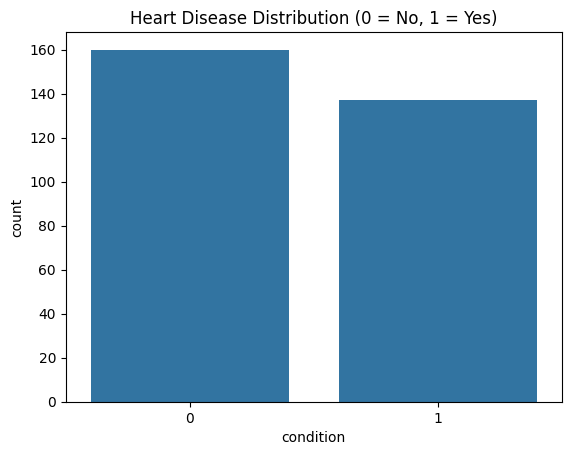

In [2]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Class distribution
sns.countplot(x='condition', data=df)
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()


# **Feature Engineering:**



In [3]:
#Step 1: Create New Features

# 1. Age Binning (categorical age group)
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=['Young', 'Middle-aged', 'Old'])

# 2. Cholesterol-to-age ratio
df['chol_age_ratio'] = df['chol'] / df['age']

# 3. Log transformation to reduce skewness
df['chol_log'] = np.log1p(df['chol'])
df['trestbps_log'] = np.log1p(df['trestbps'])

# 4. Heart Rate Reserve (Maximum HR - Resting HR) [only if 'resting_hr' exists; if not, skip]
# (Skip this unless you have a resting HR column — not present in UCI heart dataset)

# 5. Interaction Feature: Oldpeak * Age
df['oldpeak_age'] = df['oldpeak'] * df['age']

# Step 2: One-Hot Encoding of Categorical Features (like age_group)
df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

# Step 3: Final check
print(" Feature engineering done!")
print(df.head())


 Feature engineering done!
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  chol_age_ratio  chol_log  trestbps_log  oldpeak_age  \
0   1     0          0        3.391304  5.459586      5.081404          6.9   
1   2     0          0        3.463768  5.480639      4.948760        124.2   
2   0     0          0        3.424242  5.424950      5.017280        171.6   
3   1     0          1        4.338462  5.645447      4.934474         91.0   
4   0     0          0        3.296875  5.356586      4.709530        115.2   

   age_grou

# **Logistic Regression:**

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7333333333333333
Confusion Matrix:
 [[23  9]
 [ 7 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74        32
           1       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60



# **Random Forest**

In [5]:
#Step 1: Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset (assuming 'df' is already loaded from a previous cell)
# If 'df' is not loaded, you'll need to add the data loading step here as well.

# Assuming df is loaded and contains the 'condition' column
# Feature and target split
X = df.drop('condition', axis=1)
y = df['condition']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 2: Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Step 3: Predict
y_pred = rf_model.predict(X_test_scaled)

# Step 4: Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7166666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73        32
           1       0.69      0.71      0.70        28

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60

 Confusion Matrix:
 [[23  9]
 [ 8 20]]


# **Support Vector Machine:**

In [6]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

# Step 2: Load Dataset
df = pd.read_csv('/content/Heart Disease.zip')  # Change path to load the zip file directly
print(df.head())
print(df.info())

# Step 3: Check and clean data
print(df.isnull().sum())  # No missing values expected

# Step 4: Feature and Target Split
X = df.drop('condition', axis=1)
y = df['condition']

# Step 5: Balance Data using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 7: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: SVM Model Training
svm = SVC(kernel='rbf', C=1, gamma='scale')  # RBF kernel performs well for nonlinear boundaries
svm.fit(X_train_scaled, y_train)

# Step 9: Model Prediction and Evaluation
y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       29

# **K-Nearest Neighbors:**

In [7]:
# Step 1: Import required libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# Step 2: Load the dataset
df = pd.read_csv('/content/Heart Disease.zip')  # unzip and point to actual CSV inside ZIP

# Step 3: Split into features and target
X = df.drop('condition', axis=1)
y = df['condition']

# Step 4: Preprocessing - Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Step 6: KNN Model + Grid Search for Best K
param_grid = {'n_neighbors': list(range(3, 21))}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_knn.fit(X_train, y_train)

# Best model
knn_best = grid_knn.best_estimator_
y_pred = knn_best.predict(X_test)

# Step 7: Evaluation
print("Best K:", grid_knn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Best K: {'n_neighbors': 19}
Accuracy: 0.8833333333333333
Confusion Matrix:
 [[32  0]
 [ 7 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        32
           1       1.00      0.75      0.86        28

    accuracy                           0.88        60
   macro avg       0.91      0.88      0.88        60
weighted avg       0.90      0.88      0.88        60



# **Artificial Neural Network:**


In [14]:
# Step 1: Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load Dataset
df = pd.read_csv('/content/Heart Disease.zip')  # Replace with your path
print(df.head())

# Step 3: Split features and target
X = df.drop('condition', axis=1)
y = df['condition']

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Build ANN Model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Step 7: Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 8: Train Model
model.fit(X_train_scaled, y_train, epochs=20, batch_size=10, validation_split=0.1)

# Step 9: Predict
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).reshape(-1)

# Step 10: Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("✅ Classification Report:\n", classification_report(y_test, y_pred))


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7111 - loss: 0.6120 - val_accuracy: 0.7083 - val_loss: 0.5777
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8242 - loss: 0.4979 - val_accuracy: 0.8333 - val_loss: 0.5085
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8873 - loss: 0.4106 - val_accuracy: 0.8333 - val_loss: 0.4693
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8888 - loss: 0.3339 - val_accuracy: 0.8333 - val_loss: 0.4581
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9217 - loss: 0.2702 - val_accuracy: 0.8333 - val_loss: 0.4513
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8868 - loss: 0.2909 - val_accuracy: 0.8333 - val_loss: 0.4577
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8943 - loss: 0.2604 - val_accuracy: 0.8333 - val_loss: 0.4571
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9114 - loss: 0.2459 - val_accuracy: 0.8333 - val_loss: 0.4631
Ep

# **K-Fold Cross Validation:**



In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
from zipfile import ZipFile
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Step 2: Extract and Load dataset
with ZipFile('/content/Heart Disease.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
df = pd.read_csv('/content/heart_cleveland_upload.csv')  # Update if CSV name is different

# Step 3: Separate features and target
X = df.drop('condition', axis=1)
y = df['condition']

# Step 4: Initialize 4-Fold cross-validator
kf = KFold(n_splits=4, shuffle=True, random_state=42)

# Step 5: Initialize metrics lists
accuracies = []
precisions = []
recalls = []
f1s = []
conf_matrices = []

# Step 6: Loop through folds
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Standardize data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

# Step 7: Print average metrics
print("Average Accuracy:", np.mean(accuracies))
print("Average Precision:", np.mean(precisions))
print("Average Recall:", np.mean(recalls))
print("Average F1-Score:", np.mean(f1s))

# Optional: Print confusion matrix from last fold
print("\nConfusion Matrix (last fold):\n", conf_matrices[-1])


Average Accuracy: 0.8386036036036035
Average Precision: 0.8440152801358235
Average Recall: 0.8075838769804287
Average F1-Score: 0.823613749434645

Confusion Matrix (last fold):
 [[34  4]
 [ 9 27]]


# **Evaluation:**

✅ ROC AUC Score: 0.8180803571428572


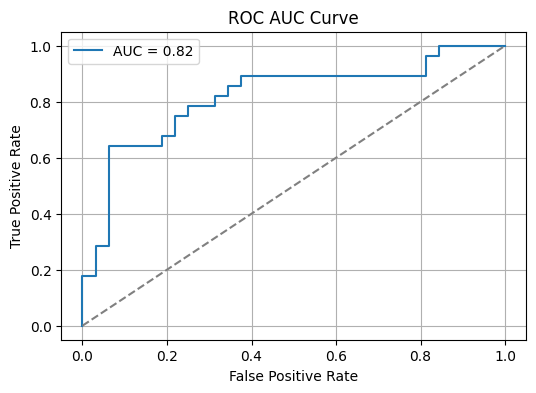

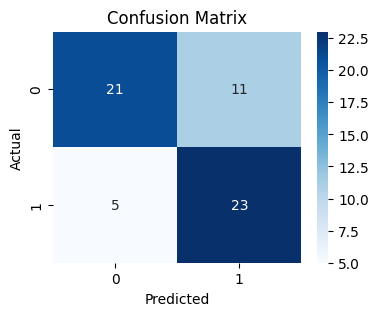

In [15]:
#ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("✅ ROC AUC Score:", roc_auc)

#Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve")
plt.legend()
plt.grid()
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
from zipfile import ZipFile
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Step 2: Extract and Load dataset
with ZipFile('/content/Heart Disease.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
df = pd.read_csv('/content/heart_cleveland_upload.csv')  # Update if CSV name is different

# Step 3: Separate features and target
X = df.drop('condition', axis=1)
y = df['condition']

# Step 4: Initialize 4-Fold cross-validator
kf = KFold(n_splits=4, shuffle=True, random_state=42)

# Step 5: Initialize metrics lists
accuracies = []
precisions = []
recalls = []
f1s = []
conf_matrices = []

# Step 6: Loop through folds
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Standardize data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    conf_matrices.append(confusion_matrix(y_test, y_pred))

# Step 7: Print average metrics
print("Average Accuracy:", np.mean(accuracies))
print("Average Precision:", np.mean(precisions))
print("Average Recall:", np.mean(recalls))
print("Average F1-Score:", np.mean(f1s))

# Optional: Print confusion matrix from last fold
print("\nConfusion Matrix (last fold):\n", conf_matrices[-1])


Average Accuracy: 0.8386036036036035
Average Precision: 0.8440152801358235
Average Recall: 0.8075838769804287
Average F1-Score: 0.823613749434645

Confusion Matrix (last fold):
 [[34  4]
 [ 9 27]]


# **Train Model and Scaler:**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import pickle

# Step 1: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train model
model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)


# **Deployment (Streamlit App):**

In [25]:
!pip install streamlit


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00


**Step 1: Train Your Model and Scaler:**

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import pickle

# Step 1: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Train model
model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)


KNeighborsClassifier()

**Step 2: Save Model and Scaler:**

In [27]:
# Save model
with open("heart_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


In [28]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load model and scaler
model = pickle.load(open("heart_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# Title
st.title("Heart Disease Prediction App")

# Collecting User Input for 13 Features
age = st.slider("Age", 20, 80)
sex = st.selectbox("Sex (1 = Male, 0 = Female)", [1, 0])
cp = st.selectbox("Chest Pain Type (0 = typical angina, 1 = atypical, 2 = non-anginal, 3 = asymptomatic)", [0, 1, 2, 3])
trestbps = st.slider("Resting Blood Pressure", 80, 200)
chol = st.slider("Cholesterol", 100, 600)
fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl (1 = True, 0 = False)", [1, 0])
restecg = st.selectbox("Resting ECG Results (0, 1, 2)", [0, 1, 2])
thalach = st.slider("Maximum Heart Rate Achieved", 60, 220)
exang = st.selectbox("Exercise Induced Angina (1 = Yes, 0 = No)", [1, 0])
oldpeak = st.slider("ST Depression", 0.0, 6.0, step=0.1)
slope = st.selectbox("Slope of the peak exercise ST segment (0,1,2)", [0, 1, 2])
ca = st.selectbox("Number of Major Vessels (0–3) Colored by Fluoroscopy", [0, 1, 2, 3])
thal = st.selectbox("Thal (1 = Normal, 2 = Fixed Defect, 3 = Reversible Defect)", [1, 2, 3])

# Convert input to array and scale
input_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg, thalach,
                        exang, oldpeak, slope, ca, thal]])
input_scaled = scaler.transform(input_data)

# Prediction
if st.button("Predict"):
    result = model.predict(input_scaled)
    if result[0] == 1:
        st.error("Heart Disease Detected!")
    else:
        st.success("No Heart Disease Detected.")


Writing app.py


In [33]:
!pip install streamlit pyngrok --quiet

In [29]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.86.228.238:8501

  Stopping...
  Stopping...


In [ ]:
!ngrok config add-authtoken 2zuHr1ayxkr2LbyMeYnpc7mqldz_r5yYbcvx2Ptas1an5BGg

from pyngrok import ngrok

# Set up tunnel
public_url = ngrok.connect(8501)
print(f"Streamlit app is live at: {public_url}")

# Run streamlit
!streamlit run app.py &

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Streamlit app is live at: NgrokTunnel: "https://e254af527bc9.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.86.228.238:8501

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
